In [ ]:
Creates a machine learning model to predict the length of stay (in days) of a
patient entering the Hospital, given various factors about their stay.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from ydata_profiling import ProfileReport
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,OrdinalEncoder
import warnings
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
import pickle
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,f1_score

In [ ]:
Data=pd.read_csv("HealthCareAnalytics.csv")

# Basic checks

In [ ]:
Data.head(10)

,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available_Extra_Rooms_in_Hospital,Department,Ward_Type,Ward_Facility_Code,Bed_Grade,patientid,City_Code_Patient,Type_of_Admission,Severity_of_Illness,Visitors_with_Patient,Age,Admission_Deposit,Stay
0,1,8,c,3,Z,3,radiotherapy,R,F,2.0,31397,7.0,Emergency,Extreme,2,51-60,4911,0-10
1,2,2,c,5,Z,2,radiotherapy,S,F,2.0,31397,7.0,Trauma,Extreme,2,51-60,5954,41-50
2,3,10,e,1,X,2,anesthesia,S,E,2.0,31397,7.0,Trauma,Extreme,2,51-60,4745,31-40
3,4,26,b,2,Y,2,radiotherapy,R,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,7272,41-50
4,5,26,b,2,Y,2,radiotherapy,S,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,5558,41-50
5,6,23,a,6,X,2,anesthesia,S,F,2.0,31397,7.0,Trauma,Extreme,2,51-60,4449,Nov-20
6,7,32,f,9,Y,1,radiotherapy,S,B,3.0,31397,7.0,Emergency,Extreme,2,51-60,6167,0-10
7,8,23,a,6,X,4,radiotherapy,Q,F,3.0,31397,7.0,Trauma,Extreme,2,51-60,5571,41-50
8,9,1,d,10,Y,2,gynecology,R,B,4.0,31397,7.0,Trauma,Extreme,2,51-60,7223,51-60
9,10,10,e,1,X,2,gynecology,S,E,3.0,31397,7.0,Trauma,Extreme,2,51-60,6056,31-40


In [ ]:
Data.head(pd.set_option('display.max_columns',None))

,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available_Extra_Rooms_in_Hospital,Department,Ward_Type,Ward_Facility_Code,Bed_Grade,patientid,City_Code_Patient,Type_of_Admission,Severity_of_Illness,Visitors_with_Patient,Age,Admission_Deposit,Stay
0,1,8,c,3,Z,3,radiotherapy,R,F,2.0,31397,7.0,Emergency,Extreme,2,51-60,4911,0-10
1,2,2,c,5,Z,2,radiotherapy,S,F,2.0,31397,7.0,Trauma,Extreme,2,51-60,5954,41-50
2,3,10,e,1,X,2,anesthesia,S,E,2.0,31397,7.0,Trauma,Extreme,2,51-60,4745,31-40
3,4,26,b,2,Y,2,radiotherapy,R,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,7272,41-50
4,5,26,b,2,Y,2,radiotherapy,S,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,5558,41-50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318433,318434,6,a,6,X,3,radiotherapy,Q,F,4.0,86499,23.0,Emergency,Moderate,3,41-50,4144,Nov-20
318434,318435,24,a,1,X,2,anesthesia,Q,E,4.0,325,8.0,Urgent,Moderate,4,81-90,6699,31-40
318435,318436,7,a,4,X,3,gynecology,R,F,4.0,125235,10.0,Emergency,Minor,3,71-80,4235,Nov-20
318436,318437,11,b,2,Y,3,anesthesia,Q,D,3.0,91081,8.0,Trauma,Minor,5,Nov-20,3761,Nov-20


In [ ]:
Data.tail()

,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available_Extra_Rooms_in_Hospital,Department,Ward_Type,Ward_Facility_Code,Bed_Grade,patientid,City_Code_Patient,Type_of_Admission,Severity_of_Illness,Visitors_with_Patient,Age,Admission_Deposit,Stay
318433,318434,6,a,6,X,3,radiotherapy,Q,F,4.0,86499,23.0,Emergency,Moderate,3,41-50,4144,Nov-20
318434,318435,24,a,1,X,2,anesthesia,Q,E,4.0,325,8.0,Urgent,Moderate,4,81-90,6699,31-40
318435,318436,7,a,4,X,3,gynecology,R,F,4.0,125235,10.0,Emergency,Minor,3,71-80,4235,Nov-20
318436,318437,11,b,2,Y,3,anesthesia,Q,D,3.0,91081,8.0,Trauma,Minor,5,Nov-20,3761,Nov-20
318437,318438,19,a,7,Y,5,gynecology,Q,C,2.0,21641,8.0,Emergency,Minor,2,Nov-20,4752,0-10


In [ ]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318438 entries, 0 to 318437
Data columns (total 18 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   case_id                            318438 non-null  int64  
 1   Hospital_code                      318438 non-null  int64  
 2   Hospital_type_code                 318438 non-null  object 
 3   City_Code_Hospital                 318438 non-null  int64  
 4   Hospital_region_code               318438 non-null  object 
 5   Available_Extra_Rooms_in_Hospital  318438 non-null  int64  
 6   Department                         318438 non-null  object 
 7   Ward_Type                          318438 non-null  object 
 8   Ward_Facility_Code                 318438 non-null  object 
 9   Bed_Grade                          318325 non-null  float64
 10  patientid                          318438 non-null  int64  
 11  City_Code_Patient                  3139

In [ ]:
Data.isnull().sum()

case_id                                 0
Hospital_code                           0
Hospital_type_code                      0
City_Code_Hospital                      0
Hospital_region_code                    0
Available_Extra_Rooms_in_Hospital       0
Department                              0
Ward_Type                               0
Ward_Facility_Code                      0
Bed_Grade                             113
patientid                               0
City_Code_Patient                    4532
Type_of_Admission                       0
Severity_of_Illness                     0
Visitors_with_Patient                   0
Age                                     0
Admission_Deposit                       0
Stay                                    0
dtype: int64

In [ ]:
Data.Bed_Grade.isnull().sum()

113

In [ ]:
Data.City_Code_Patient.isnull().sum()

4532

In [ ]:
Data.describe()

,case_id,Hospital_code,City_Code_Hospital,Available_Extra_Rooms_in_Hospital,Bed_Grade,patientid,City_Code_Patient,Visitors_with_Patient,Admission_Deposit
count,318438.000000,318438.000000,318438.000000,318438.000000,318325.000000,318438.000000,313906.000000,318438.000000,318438.000000
mean,159219.500000,18.318841,4.771717,3.197627,2.625807,65747.579472,7.251859,3.284099,4880.749392
std,91925.276847,8.633755,3.102535,1.168171,0.873146,37979.936440,4.745266,1.764061,1086.776254
min,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1800.000000
25%,79610.250000,11.000000,2.000000,2.000000,2.000000,32847.000000,4.000000,2.000000,4186.000000
50%,159219.500000,19.000000,5.000000,3.000000,3.000000,65724.500000,8.000000,3.000000,4741.000000
75%,238828.750000,26.000000,7.000000,4.000000,3.000000,98470.000000,8.000000,4.000000,5409.000000
max,318438.000000,32.000000,13.000000,24.000000,4.000000,131624.000000,38.000000,32.000000,11008.000000


In [ ]:
Data.describe().T

,count,mean,std,min,25%,50%,75%,max
case_id,318438.0,159219.500000,91925.276847,1.0,79610.25,159219.5,238828.75,318438.0
Hospital_code,318438.0,18.318841,8.633755,1.0,11.00,19.0,26.00,32.0
City_Code_Hospital,318438.0,4.771717,3.102535,1.0,2.00,5.0,7.00,13.0
Available_Extra_Rooms_in_Hospital,318438.0,3.197627,1.168171,0.0,2.00,3.0,4.00,24.0
Bed_Grade,318325.0,2.625807,0.873146,1.0,2.00,3.0,3.00,4.0
patientid,318438.0,65747.579472,37979.936440,1.0,32847.00,65724.5,98470.00,131624.0
City_Code_Patient,313906.0,7.251859,4.745266,1.0,4.00,8.0,8.00,38.0
Visitors_with_Patient,318438.0,3.284099,1.764061,0.0,2.00,3.0,4.00,32.0
Admission_Deposit,318438.0,4880.749392,1086.776254,1800.0,4186.00,4741.0,5409.00,11008.0


In [ ]:
Data.describe(include=['O'])

,Hospital_type_code,Hospital_region_code,Department,Ward_Type,Ward_Facility_Code,Type_of_Admission,Severity_of_Illness,Age,Stay
count,318438,318438,318438,318438,318438,318438,318438,318438,318438
unique,7,3,5,6,6,3,3,10,11
top,a,X,gynecology,R,F,Trauma,Moderate,41-50,21-30
freq,143425,133336,249486,127947,112753,152261,175843,63749,87491


In [ ]:
Data.shape

(318438, 18)

In [ ]:
## Insights

# In Bed_Grade we have 113 null values and in City_code_patient we have 4532 null values.
# There is no constant features in any column.
# CaseId is a unique feature. not required.



# Exploratory Data Analysis

# Univariate Analysis

In [ ]:
import sweetviz as sv
my_report=sv.analyze(Data)
my_report.show_html()

                                             |                                             | [  0%]   00:00 ->…

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [ ]:
## Insights from Univariate Analysis

# 40% of the hospital region code belongs to x.
# 60% of the Extra rooms are available around 3 to 4 per day in a hospital.
# 80% of the patients are in the gynocology department.
# severity of illness is about 60% is moderate and extreme near 17%.
# 60% visitors with patients are 3 to 4 people.

# Bivariate Analysis

# Checking relationship of all variables with respect to target variable

# Categorical data

In [ ]:
Data.select_dtypes(include=['O']).columns


Index(['Hospital_type_code', 'Hospital_region_code', 'Department', 'Ward_Type',
       'Ward_Facility_Code', 'Type_of_Admission', 'Severity_of_Illness', 'Age',
       'Stay'],
      dtype='object')

In [ ]:
# create a new dataframe with categorical columns only
Data1=Data[['Hospital_type_code', 'Hospital_region_code', 'Department', 'Ward_Type',
       'Ward_Facility_Code', 'Type_of_Admission', 'Severity_of_Illness', 'Age',
       'Stay']]


In [ ]:
Data1   ##new data frame with categorical columns only

,Hospital_type_code,Hospital_region_code,Department,Ward_Type,Ward_Facility_Code,Type_of_Admission,Severity_of_Illness,Age,Stay
0,c,Z,radiotherapy,R,F,Emergency,Extreme,51-60,0-10
1,c,Z,radiotherapy,S,F,Trauma,Extreme,51-60,41-50
2,e,X,anesthesia,S,E,Trauma,Extreme,51-60,31-40
3,b,Y,radiotherapy,R,D,Trauma,Extreme,51-60,41-50
4,b,Y,radiotherapy,S,D,Trauma,Extreme,51-60,41-50
...,...,...,...,...,...,...,...,...,...
318433,a,X,radiotherapy,Q,F,Emergency,Moderate,41-50,Nov-20
318434,a,X,anesthesia,Q,E,Urgent,Moderate,81-90,31-40
318435,a,X,gynecology,R,F,Emergency,Minor,71-80,Nov-20
318436,b,Y,anesthesia,Q,D,Trauma,Minor,Nov-20,Nov-20


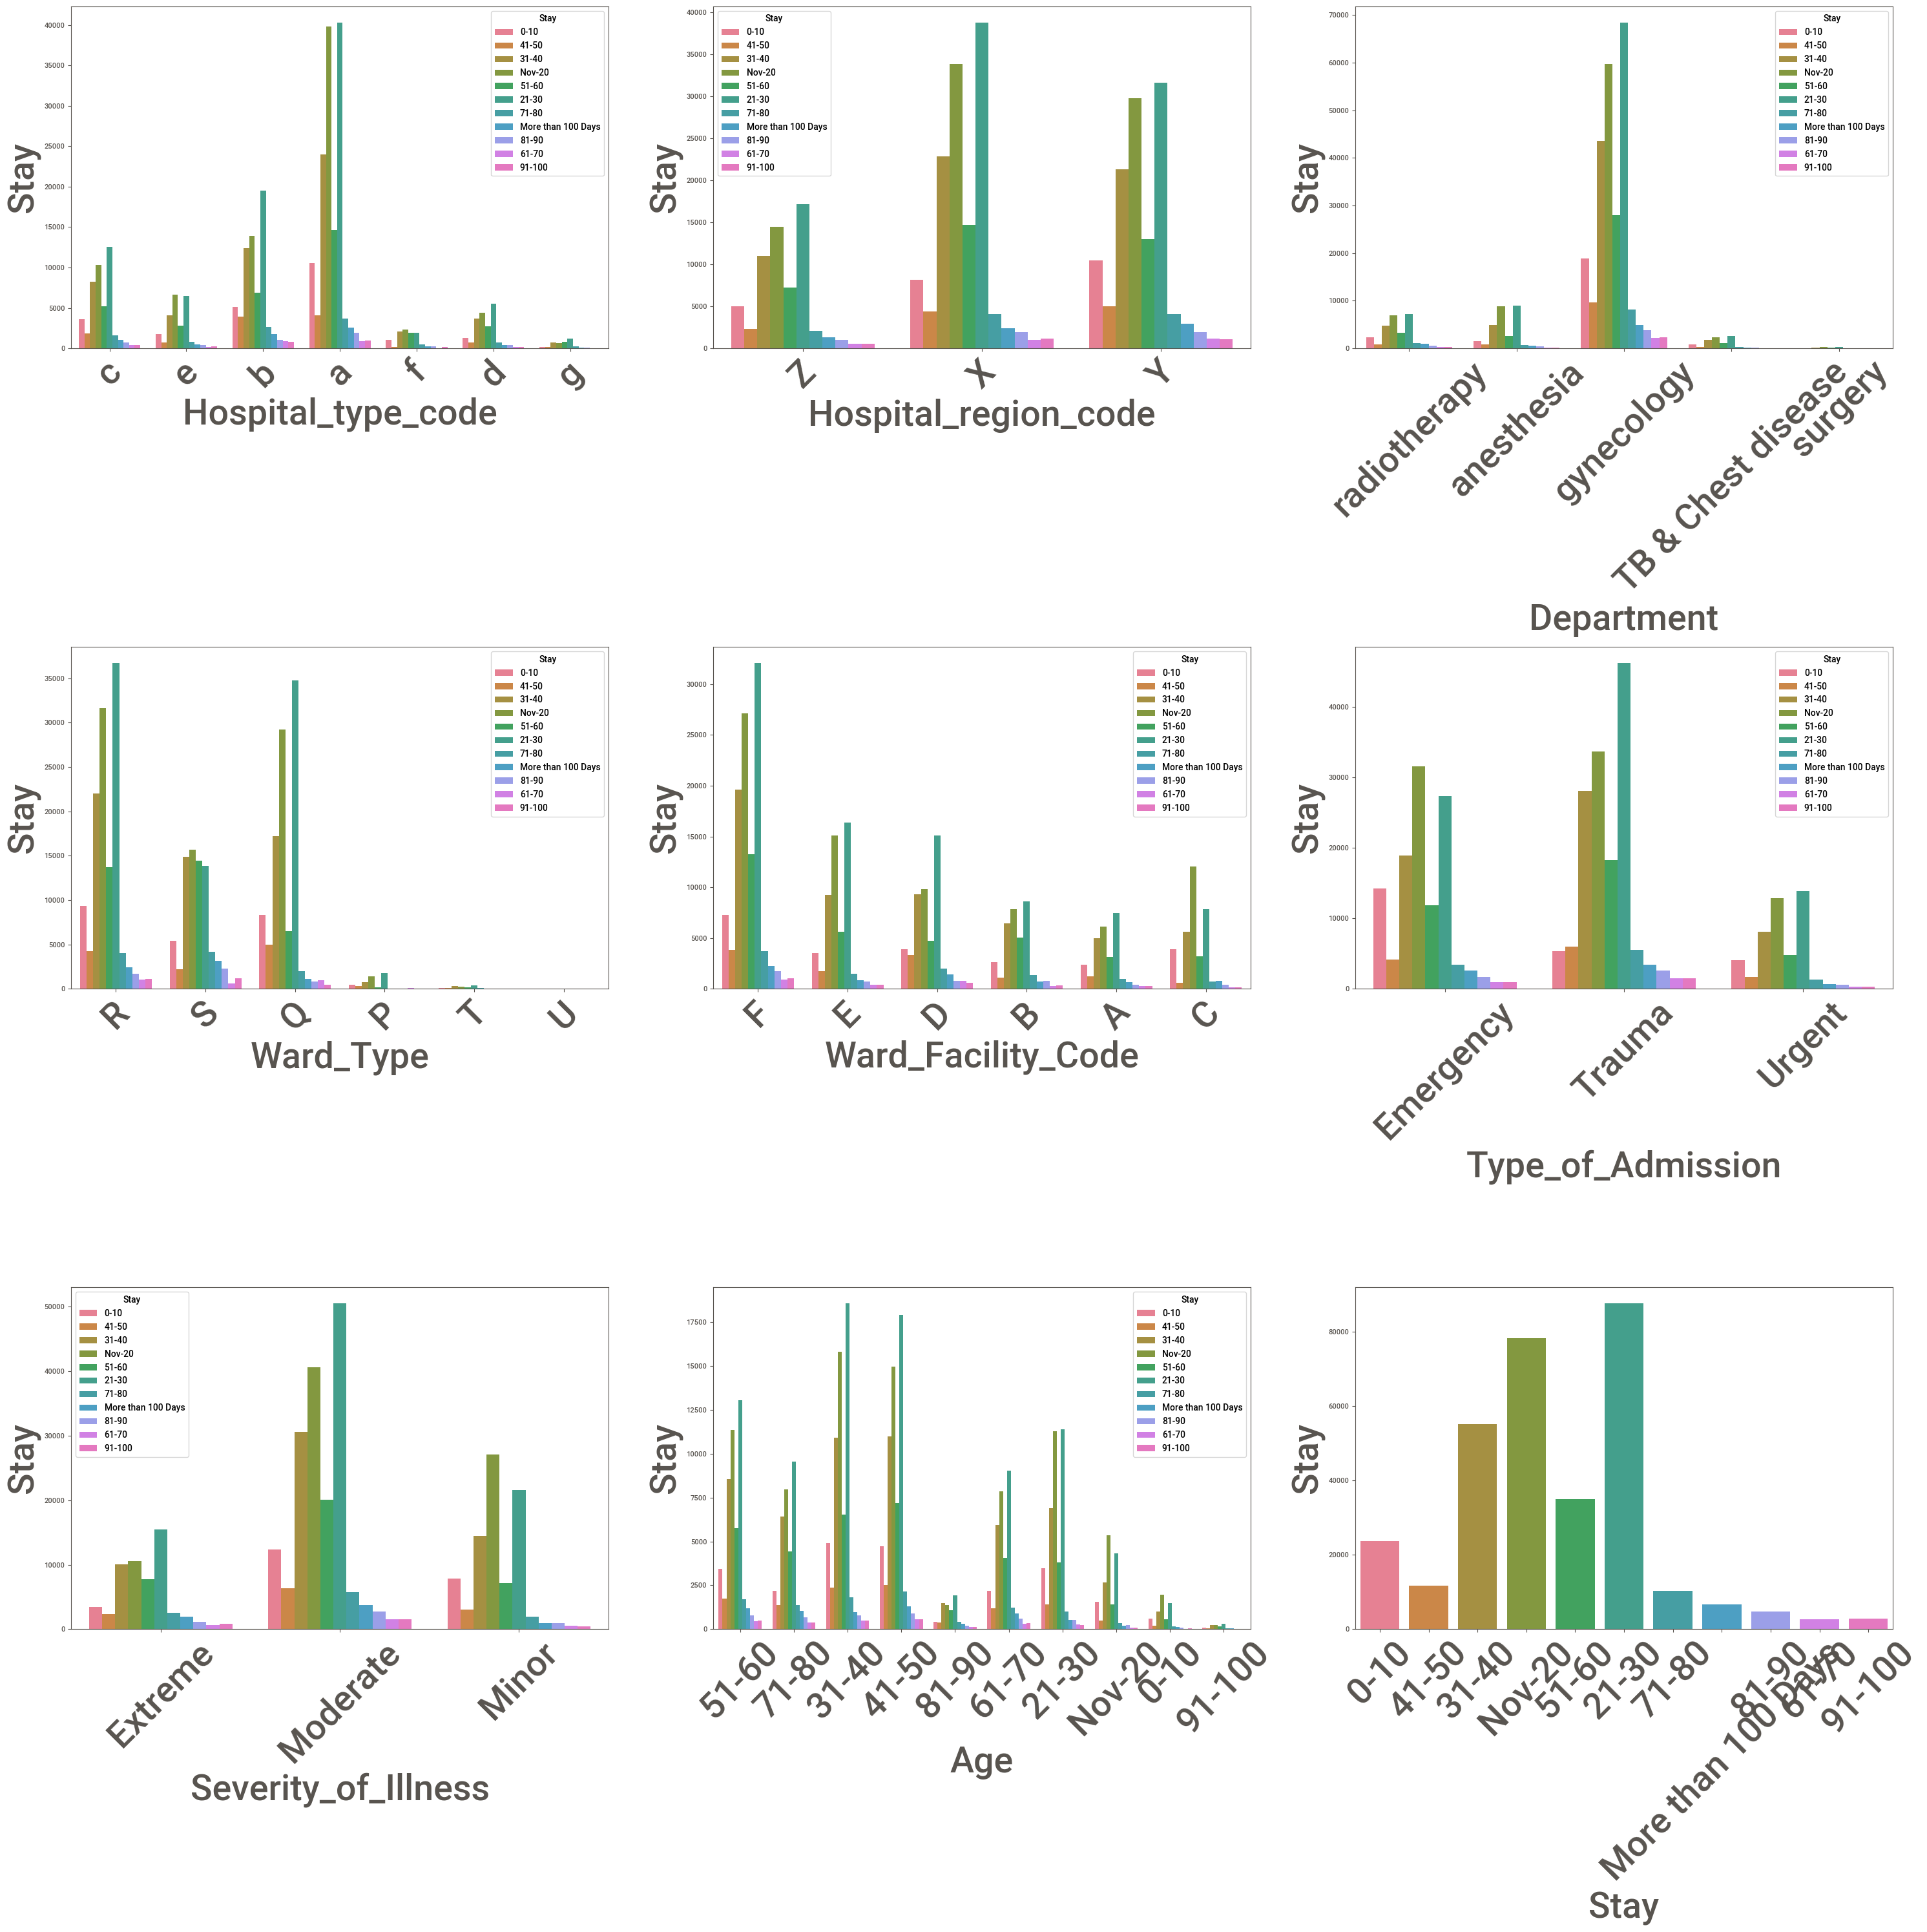

In [ ]:
# plotting how every categorical feature correlate with the target
plt.figure(figsize=(30,30), facecolor='white')
plotnumber = 1

for column in Data1:
    if plotnumber<=16 :
        ax = plt.subplot(3, 3,plotnumber)
        sns.countplot(x=Data1[column].dropna(axis=0),hue=Data.Stay)
        plt.xlabel(column,fontsize=40)
        plt.ylabel('Stay',fontsize=40)
        plt.xticks(fontsize=40,rotation=45)
    plotnumber+=1
plt.tight_layout()
plt.show()

In [ ]:
# Hospital_type_code 'a' has highest patient volume. most patients stay between 21-30 and 51-60.
# Hospital_region_code 'x' has highest patient volume. most patients stay between 21-30 and 51-60.
# Highest patients are in the gynecology department . most patients stay beyween 21-30 and 51-60.
# ward_type 'R' has highest patient volume. most patients stay between 21-30 and 51-60.
# ward_facility_code 'F' has highest patient volume.most patients stay between 21-30.
# Type_of_Admission 'Trauma' has highest pateint volume. most patients stay between 21-30 and 51-60.
# In Type of serverity_of_illness 'Moderate' part have highest patient volume.
# Age between 31-40 and 41-50 highest patients stay in hospital.



# Discrete data

In [ ]:
Data.select_dtypes(include=['int64', 'float64']).columns

Index(['case_id', 'Hospital_code', 'City_Code_Hospital',
       'Available_Extra_Rooms_in_Hospital', 'Bed_Grade', 'patientid',
       'City_Code_Patient', 'Visitors_with_Patient', 'Admission_Deposit'],
      dtype='object')

In [ ]:
Data2=Data[['Hospital_code', 'City_Code_Hospital',
       'Available_Extra_Rooms_in_Hospital', 'Bed_Grade', 'patientid',
       'City_Code_Patient', 'Visitors_with_Patient', 'Admission_Deposit']]

In [ ]:
Data2

,Hospital_code,City_Code_Hospital,Available_Extra_Rooms_in_Hospital,Bed_Grade,patientid,City_Code_Patient,Visitors_with_Patient,Admission_Deposit
0,8,3,3,2.0,31397,7.0,2,4911
1,2,5,2,2.0,31397,7.0,2,5954
2,10,1,2,2.0,31397,7.0,2,4745
3,26,2,2,2.0,31397,7.0,2,7272
4,26,2,2,2.0,31397,7.0,2,5558
...,...,...,...,...,...,...,...,...
318433,6,6,3,4.0,86499,23.0,3,4144
318434,24,1,2,4.0,325,8.0,4,6699
318435,7,4,3,4.0,125235,10.0,3,4235
318436,11,2,3,3.0,91081,8.0,5,3761


In [ ]:
Data2.drop('patientid', axis=1, inplace=True)

In [ ]:
Data2.drop('Admission_Deposit', axis=1, inplace=True)

In [ ]:
Data2.head()

,Hospital_code,City_Code_Hospital,Available_Extra_Rooms_in_Hospital,Bed_Grade,City_Code_Patient,Visitors_with_Patient
0,8,3,3,2.0,7.0,2
1,2,5,2,2.0,7.0,2
2,10,1,2,2.0,7.0,2
3,26,2,2,2.0,7.0,2
4,26,2,2,2.0,7.0,2


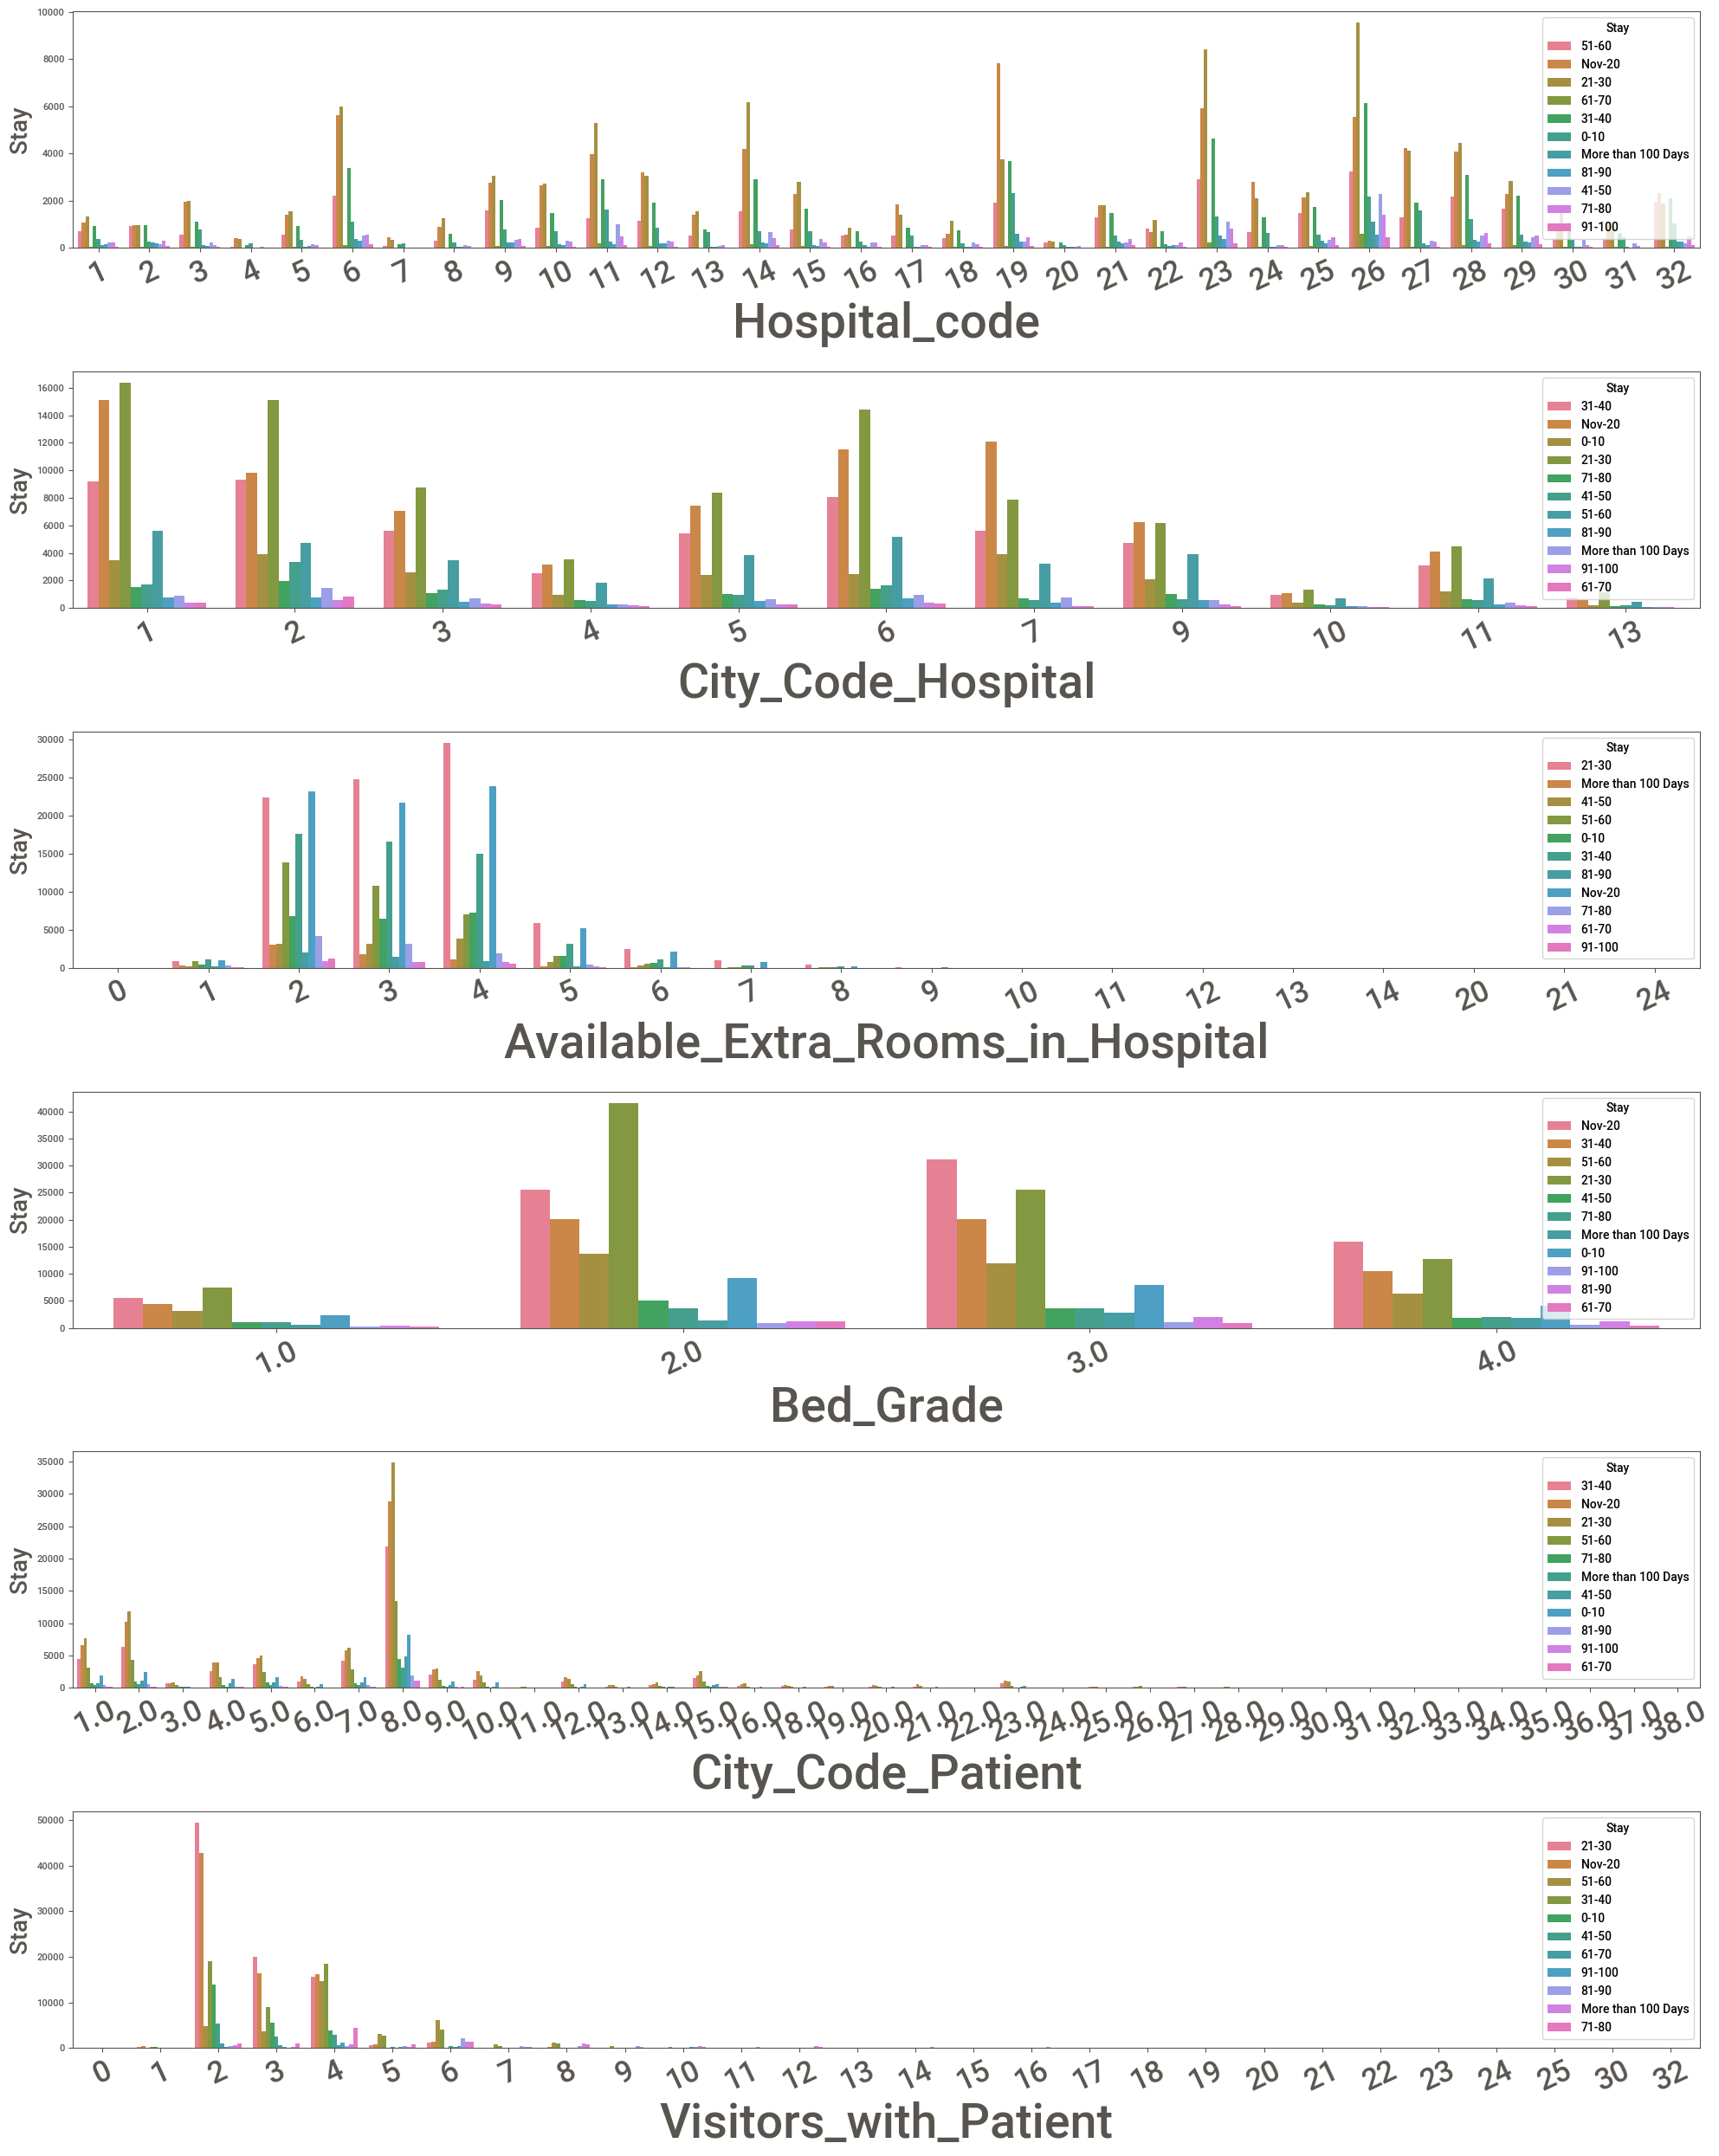

In [ ]:
# plotting how every discrete feature correlate with the target
plt.figure(figsize=(20,25), facecolor='white')
plotnumber = 1

for column in Data2:
    if plotnumber<=6 :
        ax = plt.subplot(6, 1,plotnumber)
        sns.countplot(x=Data2[column].dropna(axis=0),hue=Data.Stay)
        plt.xlabel(column,fontsize=40)
        plt.ylabel('Stay',fontsize=20)
        plt.xticks(fontsize=25,rotation=25)
    plotnumber+=1
plt.tight_layout()
plt.show()

In [ ]:
## Insights
# Hospital_Code '26' has highest patient volume. most patients stay between 21-30 days.
# City_code_Hospital '1' has highest patient volume. most patients stay btweem 21-30 days.
# Mostly hospital have 4 extra rooms, showing high occupancy. Patients in these hospitals mainly stay between 21–30 days.
# Bed Grade 2–3 handle most patients, mainly staying 21–30 days, while Bed Grade 1 has fewer admissions.
# Only a few patient city codes (especially around 4–8) show high admission volume, with most patients staying 21–30 days. Many other city codes have very few admissions.
#Most patients have 2–4 visitors, and their stay is commonly around 21–30 days.

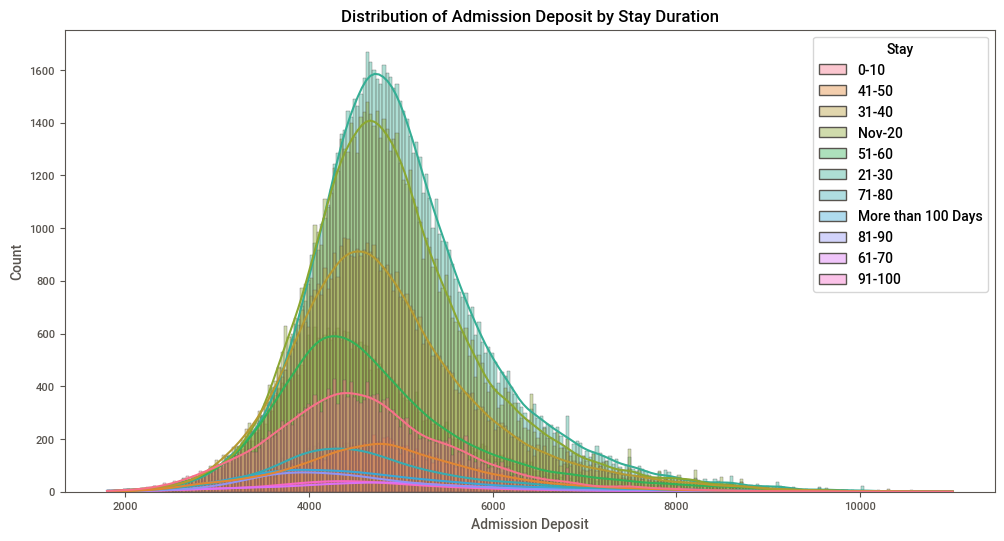

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.histplot(
    data=Data,
    x='Admission_Deposit',
    hue='Stay',
    kde=True,
    multiple='layer',     # or 'stack' / 'dodge'
    alpha=0.4
)

plt.xlabel("Admission Deposit")
plt.ylabel("Count")
plt.title("Distribution of Admission Deposit by Stay Duration")
plt.show()

In [ ]:
# Insights
#Admission deposits are mostly concentrated around ₹3800–₹5200 for all stay durations, showing uniform pricing.

# Data Preprocessing

In [ ]:
Data.isnull().sum()

case_id                                 0
Hospital_code                           0
Hospital_type_code                      0
City_Code_Hospital                      0
Hospital_region_code                    0
Available_Extra_Rooms_in_Hospital       0
Department                              0
Ward_Type                               0
Ward_Facility_Code                      0
Bed_Grade                             113
patientid                               0
City_Code_Patient                    4532
Type_of_Admission                       0
Severity_of_Illness                     0
Visitors_with_Patient                   0
Age                                     0
Admission_Deposit                       0
Stay                                    0
dtype: int64

In [ ]:
Data.head()

,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available_Extra_Rooms_in_Hospital,Department,Ward_Type,Ward_Facility_Code,Bed_Grade,patientid,City_Code_Patient,Type_of_Admission,Severity_of_Illness,Visitors_with_Patient,Age,Admission_Deposit,Stay
0,1,8,c,3,Z,3,radiotherapy,R,F,2.0,31397,7.0,Emergency,Extreme,2,51-60,4911,0-10
1,2,2,c,5,Z,2,radiotherapy,S,F,2.0,31397,7.0,Trauma,Extreme,2,51-60,5954,41-50
2,3,10,e,1,X,2,anesthesia,S,E,2.0,31397,7.0,Trauma,Extreme,2,51-60,4745,31-40
3,4,26,b,2,Y,2,radiotherapy,R,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,7272,41-50
4,5,26,b,2,Y,2,radiotherapy,S,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,5558,41-50


In [ ]:
# There is invalid values 'nov-20' in columns age and stay.

In [ ]:
Data[(Data['Age']=="Nov-20") | (Data['Stay']=="Nov-20")]

,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available_Extra_Rooms_in_Hospital,Department,Ward_Type,Ward_Facility_Code,Bed_Grade,patientid,City_Code_Patient,Type_of_Admission,Severity_of_Illness,Visitors_with_Patient,Age,Admission_Deposit,Stay
5,6,23,a,6,X,2,anesthesia,S,F,2.0,31397,7.0,Trauma,Extreme,2,51-60,4449,Nov-20
11,12,26,b,2,Y,4,radiotherapy,R,D,1.0,31397,7.0,Urgent,Extreme,2,51-60,5993,Nov-20
17,18,29,a,4,X,4,anesthesia,S,F,3.0,63418,8.0,Emergency,Extreme,2,71-80,5342,Nov-20
22,23,21,c,3,Z,2,anesthesia,S,A,3.0,63418,8.0,Trauma,Extreme,2,71-80,6364,Nov-20
25,26,28,b,11,X,4,gynecology,R,F,2.0,8088,2.0,Emergency,Moderate,2,31-40,2405,Nov-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318432,318433,26,b,2,Y,2,anesthesia,R,D,3.0,36018,6.0,Emergency,Minor,3,Nov-20,8308,21-30
318433,318434,6,a,6,X,3,radiotherapy,Q,F,4.0,86499,23.0,Emergency,Moderate,3,41-50,4144,Nov-20
318435,318436,7,a,4,X,3,gynecology,R,F,4.0,125235,10.0,Emergency,Minor,3,71-80,4235,Nov-20
318436,318437,11,b,2,Y,3,anesthesia,Q,D,3.0,91081,8.0,Trauma,Minor,5,Nov-20,3761,Nov-20


In [ ]:
Data.loc[Data['Age'] == "Nov-20", 'Age'] = np.nan


In [ ]:
Data.loc[Data['Stay'] == "Nov-20", 'Stay'] = np.nan

In [ ]:
Data

,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available_Extra_Rooms_in_Hospital,Department,Ward_Type,Ward_Facility_Code,Bed_Grade,patientid,City_Code_Patient,Type_of_Admission,Severity_of_Illness,Visitors_with_Patient,Age,Admission_Deposit,Stay
0,1,8,c,3,Z,3,radiotherapy,R,F,2.0,31397,7.0,Emergency,Extreme,2,51-60,4911,0-10
1,2,2,c,5,Z,2,radiotherapy,S,F,2.0,31397,7.0,Trauma,Extreme,2,51-60,5954,41-50
2,3,10,e,1,X,2,anesthesia,S,E,2.0,31397,7.0,Trauma,Extreme,2,51-60,4745,31-40
3,4,26,b,2,Y,2,radiotherapy,R,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,7272,41-50
4,5,26,b,2,Y,2,radiotherapy,S,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,5558,41-50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318433,318434,6,a,6,X,3,radiotherapy,Q,F,4.0,86499,23.0,Emergency,Moderate,3,41-50,4144,NaN
318434,318435,24,a,1,X,2,anesthesia,Q,E,4.0,325,8.0,Urgent,Moderate,4,81-90,6699,31-40
318435,318436,7,a,4,X,3,gynecology,R,F,4.0,125235,10.0,Emergency,Minor,3,71-80,4235,NaN
318436,318437,11,b,2,Y,3,anesthesia,Q,D,3.0,91081,8.0,Trauma,Minor,5,NaN,3761,NaN


In [ ]:
Data.isnull().sum()

case_id                                  0
Hospital_code                            0
Hospital_type_code                       0
City_Code_Hospital                       0
Hospital_region_code                     0
Available_Extra_Rooms_in_Hospital        0
Department                               0
Ward_Type                                0
Ward_Facility_Code                       0
Bed_Grade                              113
patientid                                0
City_Code_Patient                     4532
Type_of_Admission                        0
Severity_of_Illness                      0
Visitors_with_Patient                    0
Age                                  16768
Admission_Deposit                        0
Stay                                 78139
dtype: int64

In [ ]:
Data['Age'].mode()

0    41-50
Name: Age, dtype: object

In [ ]:
Data.loc[Data["Age"].isna(), "Age"]=Data["Age"].mode()[0]

In [ ]:
Data.loc[Data["Stay"].isna(), "Stay"]=Data["Stay"].mode()[0]

In [ ]:
Data

,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available_Extra_Rooms_in_Hospital,Department,Ward_Type,Ward_Facility_Code,Bed_Grade,patientid,City_Code_Patient,Type_of_Admission,Severity_of_Illness,Visitors_with_Patient,Age,Admission_Deposit,Stay
0,1,8,c,3,Z,3,radiotherapy,R,F,2.0,31397,7.0,Emergency,Extreme,2,51-60,4911,0-10
1,2,2,c,5,Z,2,radiotherapy,S,F,2.0,31397,7.0,Trauma,Extreme,2,51-60,5954,41-50
2,3,10,e,1,X,2,anesthesia,S,E,2.0,31397,7.0,Trauma,Extreme,2,51-60,4745,31-40
3,4,26,b,2,Y,2,radiotherapy,R,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,7272,41-50
4,5,26,b,2,Y,2,radiotherapy,S,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,5558,41-50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318433,318434,6,a,6,X,3,radiotherapy,Q,F,4.0,86499,23.0,Emergency,Moderate,3,41-50,4144,21-30
318434,318435,24,a,1,X,2,anesthesia,Q,E,4.0,325,8.0,Urgent,Moderate,4,81-90,6699,31-40
318435,318436,7,a,4,X,3,gynecology,R,F,4.0,125235,10.0,Emergency,Minor,3,71-80,4235,21-30
318436,318437,11,b,2,Y,3,anesthesia,Q,D,3.0,91081,8.0,Trauma,Minor,5,41-50,3761,21-30


In [ ]:
Data['Bed_Grade'].unique()

array([ 2.,  3.,  4.,  1., nan])

In [ ]:
Data.loc[Data['Bed_Grade'].isna(),'Bed_Grade']=Data['Bed_Grade'].mode()[0]

In [ ]:
Data['City_Code_Patient'].unique()

array([ 7.,  8.,  2.,  5.,  6.,  3.,  4.,  1.,  9., 14., nan, 25., 15.,
       12., 10., 28., 24., 23., 20., 11., 13., 21., 18., 16., 26., 27.,
       22., 19., 31., 34., 32., 30., 29., 37., 33., 35., 36., 38.])

In [ ]:
Data.loc[Data['City_Code_Patient'].isna(), 'City_Code_Patient'] = Data['City_Code_Patient'].mode()[0]

In [ ]:
Data.isnull().sum()

case_id                              0
Hospital_code                        0
Hospital_type_code                   0
City_Code_Hospital                   0
Hospital_region_code                 0
Available_Extra_Rooms_in_Hospital    0
Department                           0
Ward_Type                            0
Ward_Facility_Code                   0
Bed_Grade                            0
patientid                            0
City_Code_Patient                    0
Type_of_Admission                    0
Severity_of_Illness                  0
Visitors_with_Patient                0
Age                                  0
Admission_Deposit                    0
Stay                                 0
dtype: int64

# checking Outliears

In [ ]:
data = [
    'Available_Extra_Rooms_in_Hospital',
    'Visitors_with_Patient',
    'Admission_Deposit',
    'Bed_Grade'
]

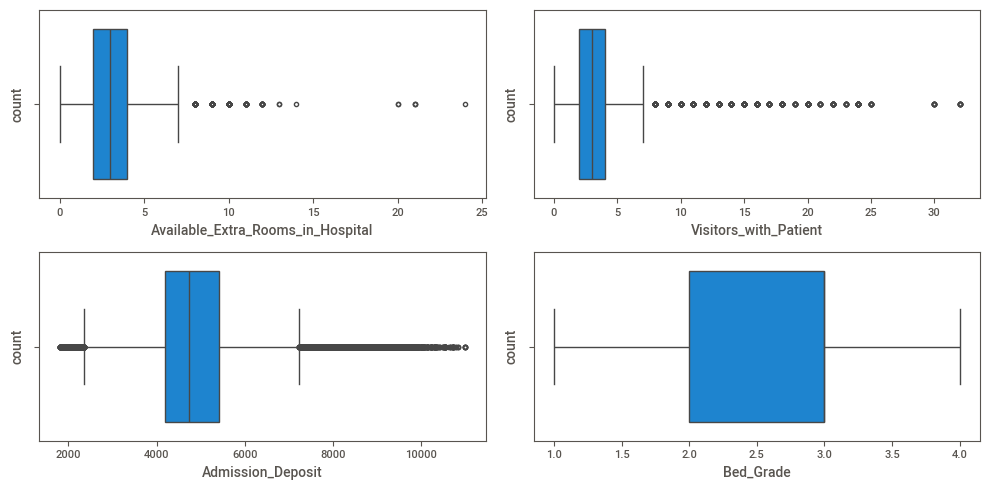

In [ ]:
plt.figure(figsize=(10,5))
plotnumber=1

for column in data:
    if plotnumber<=4:
        ax=plt.subplot(2,2,plotnumber)
        sns.boxplot(x=Data[column])
        plt.xlabel(column,fontsize=10)
        plt.ylabel("count",fontsize=10)
    plotnumber+=1
plt.tight_layout()
plt.show()

In [ ]:
# In columns Available_extra_rooms_in_hospital,Admission_deposit and visitors_with_patient keeping outliears.because these are realistic values.


# Encoding

In [ ]:
# One-Hot encoding

nominal_cols = [
    "Hospital_region_code",
    "Department",
    "Ward_Type",
    "Type_of_Admission",
    "Hospital_type_code"   # Important
]

Data=pd.get_dummies(Data,columns=nominal_cols,drop_first=True)

In [ ]:
Data = pd.get_dummies(Data, columns=["Ward_Facility_Code"], drop_first=True)


In [ ]:
Data

,case_id,Hospital_code,City_Code_Hospital,Available_Extra_Rooms_in_Hospital,Bed_Grade,patientid,City_Code_Patient,Severity_of_Illness,Visitors_with_Patient,Age,Admission_Deposit,Stay,Hospital_region_code_Y,Hospital_region_code_Z,Department_anesthesia,Department_gynecology,Department_radiotherapy,Department_surgery,Ward_Type_Q,Ward_Type_R,Ward_Type_S,Ward_Type_T,Ward_Type_U,Type_of_Admission_Trauma,Type_of_Admission_Urgent,Hospital_type_code_b,Hospital_type_code_c,Hospital_type_code_d,Hospital_type_code_e,Hospital_type_code_f,Hospital_type_code_g,Ward_Facility_Code_B,Ward_Facility_Code_C,Ward_Facility_Code_D,Ward_Facility_Code_E,Ward_Facility_Code_F
0,1,8,3,3,2.0,31397,7.0,Extreme,2,51-60,4911,0-10,False,True,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
1,2,2,5,2,2.0,31397,7.0,Extreme,2,51-60,5954,41-50,False,True,False,False,True,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True
2,3,10,1,2,2.0,31397,7.0,Extreme,2,51-60,4745,31-40,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False
3,4,26,2,2,2.0,31397,7.0,Extreme,2,51-60,7272,41-50,True,False,False,False,True,False,False,True,False,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False
4,5,26,2,2,2.0,31397,7.0,Extreme,2,51-60,5558,41-50,True,False,False,False,True,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318433,318434,6,6,3,4.0,86499,23.0,Moderate,3,41-50,4144,21-30,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
318434,318435,24,1,2,4.0,325,8.0,Moderate,4,81-90,6699,31-40,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False
318435,318436,7,4,3,4.0,125235,10.0,Minor,3,71-80,4235,21-30,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
318436,318437,11,2,3,3.0,91081,8.0,Minor,5,41-50,3761,21-30,True,False,True,False,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False


In [ ]:
bool_cols = Data.select_dtypes(include=["bool"]).columns
Data[bool_cols] = Data[bool_cols].astype(int)

In [ ]:
Data


,case_id,Hospital_code,City_Code_Hospital,Available_Extra_Rooms_in_Hospital,Bed_Grade,patientid,City_Code_Patient,Severity_of_Illness,Visitors_with_Patient,Age,Admission_Deposit,Stay,Hospital_region_code_Y,Hospital_region_code_Z,Department_anesthesia,Department_gynecology,Department_radiotherapy,Department_surgery,Ward_Type_Q,Ward_Type_R,Ward_Type_S,Ward_Type_T,Ward_Type_U,Type_of_Admission_Trauma,Type_of_Admission_Urgent,Hospital_type_code_b,Hospital_type_code_c,Hospital_type_code_d,Hospital_type_code_e,Hospital_type_code_f,Hospital_type_code_g,Ward_Facility_Code_B,Ward_Facility_Code_C,Ward_Facility_Code_D,Ward_Facility_Code_E,Ward_Facility_Code_F
0,1,8,3,3,2.0,31397,7.0,Extreme,2,51-60,4911,0-10,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1
1,2,2,5,2,2.0,31397,7.0,Extreme,2,51-60,5954,41-50,0,1,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1
2,3,10,1,2,2.0,31397,7.0,Extreme,2,51-60,4745,31-40,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0
3,4,26,2,2,2.0,31397,7.0,Extreme,2,51-60,7272,41-50,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0
4,5,26,2,2,2.0,31397,7.0,Extreme,2,51-60,5558,41-50,1,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318433,318434,6,6,3,4.0,86499,23.0,Moderate,3,41-50,4144,21-30,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
318434,318435,24,1,2,4.0,325,8.0,Moderate,4,81-90,6699,31-40,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0
318435,318436,7,4,3,4.0,125235,10.0,Minor,3,71-80,4235,21-30,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
318436,318437,11,2,3,3.0,91081,8.0,Minor,5,41-50,3761,21-30,1,0,1,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
Data["Age"].value_counts()

Age
41-50     80517
31-40     63639
51-60     48514
21-30     40843
71-80     35792
61-70     33687
81-90      7890
0-10       6254
91-100     1302
Name: count, dtype: int64

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

age_order = [["0-10","21-30","31-40","41-50","51-60",
              "61-70","71-80","81-90","91-100"]]
Data["Age"] = OrdinalEncoder(categories=age_order).fit_transform(Data[["Age"]]).astype(int)

In [ ]:
Data['Stay'].value_counts()

Stay
21-30                 165630
31-40                  55159
51-60                  35018
0-10                   23604
41-50                  11743
71-80                  10254
More than 100 Days      6683
81-90                   4838
91-100                  2765
61-70                   2744
Name: count, dtype: int64

In [ ]:
stay_order = [["0-10","21-30","31-40","41-50","51-60",
              "61-70","71-80","81-90","91-100","More than 100 Days"]]
Data["Stay"] = OrdinalEncoder(categories=stay_order).fit_transform(Data[["Stay"]]).astype(int)

In [ ]:
Data['Severity_of_Illness'].value_counts()

Severity_of_Illness
Moderate    175843
Minor        85872
Extreme      56723
Name: count, dtype: int64

In [ ]:
Severity_of_Illness_order = [["Minor","Moderate","Extreme"]]
Data["Severity_of_Illness"] = OrdinalEncoder(categories=Severity_of_Illness_order).fit_transform(Data[["Severity_of_Illness"]]).astype(int)

In [ ]:
Data

,case_id,Hospital_code,City_Code_Hospital,Available_Extra_Rooms_in_Hospital,Bed_Grade,patientid,City_Code_Patient,Severity_of_Illness,Visitors_with_Patient,Age,Admission_Deposit,Stay,Hospital_region_code_Y,Hospital_region_code_Z,Department_anesthesia,Department_gynecology,Department_radiotherapy,Department_surgery,Ward_Type_Q,Ward_Type_R,Ward_Type_S,Ward_Type_T,Ward_Type_U,Type_of_Admission_Trauma,Type_of_Admission_Urgent,Hospital_type_code_b,Hospital_type_code_c,Hospital_type_code_d,Hospital_type_code_e,Hospital_type_code_f,Hospital_type_code_g,Ward_Facility_Code_B,Ward_Facility_Code_C,Ward_Facility_Code_D,Ward_Facility_Code_E,Ward_Facility_Code_F
0,1,8,3,3,2.0,31397,7.0,2,2,4,4911,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1
1,2,2,5,2,2.0,31397,7.0,2,2,4,5954,3,0,1,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1
2,3,10,1,2,2.0,31397,7.0,2,2,4,4745,2,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0
3,4,26,2,2,2.0,31397,7.0,2,2,4,7272,3,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0
4,5,26,2,2,2.0,31397,7.0,2,2,4,5558,3,1,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318433,318434,6,6,3,4.0,86499,23.0,1,3,3,4144,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
318434,318435,24,1,2,4.0,325,8.0,1,4,7,6699,2,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0
318435,318436,7,4,3,4.0,125235,10.0,0,3,6,4235,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
318436,318437,11,2,3,3.0,91081,8.0,0,5,3,3761,1,1,0,1,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0


# Feature Selection


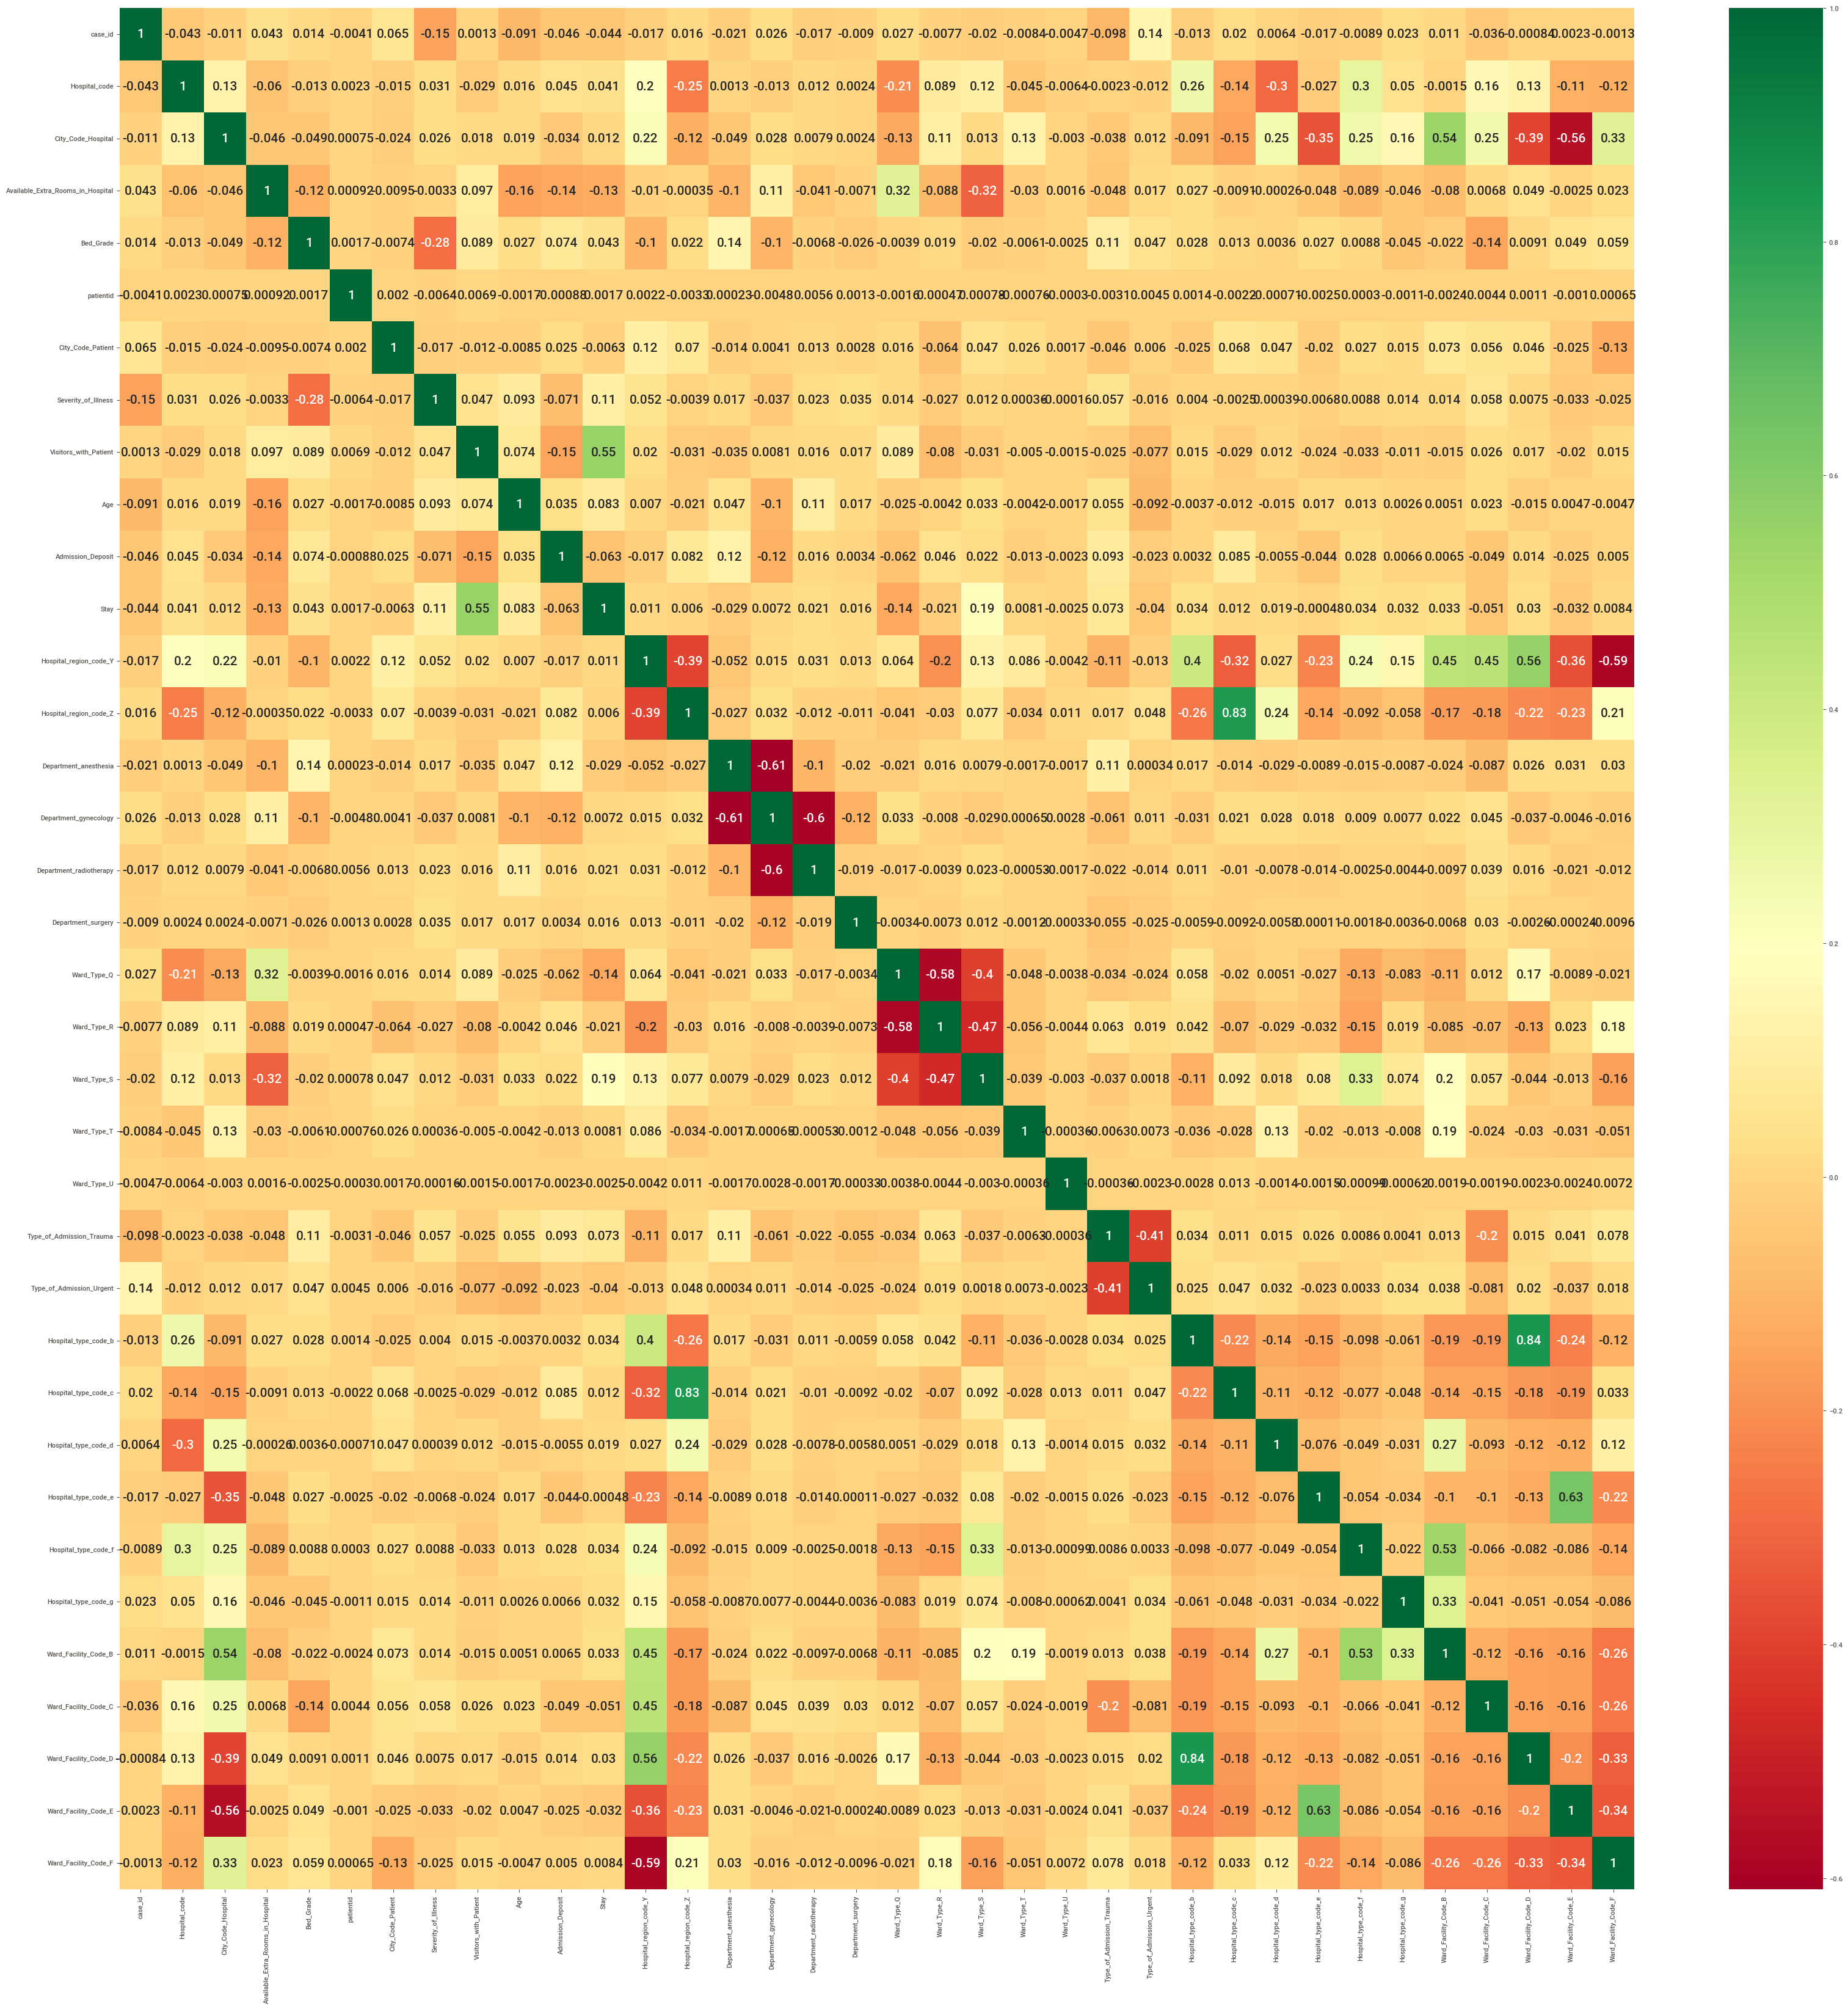

In [ ]:
# checking correlation

plt.figure(figsize=(40,40))
sns.heatmap(Data.corr(),annot=True,cmap='RdYlGn',annot_kws={'size':15})
plt.show()

In [ ]:
Data.drop(['case_id','patientid'],axis='columns',inplace=True)

In [ ]:
Data.to_csv("cleaned_data.csv", index=False)


NameError: name 'Data' is not defined

In [ ]:
import pandas as pd
Data = pd.read_csv("cleaned_data.csv")

In [ ]:
Data

,Hospital_code,City_Code_Hospital,Available_Extra_Rooms_in_Hospital,Bed_Grade,City_Code_Patient,Severity_of_Illness,Visitors_with_Patient,Age,Admission_Deposit,Stay,...,Hospital_type_code_c,Hospital_type_code_d,Hospital_type_code_e,Hospital_type_code_f,Hospital_type_code_g,Ward_Facility_Code_B,Ward_Facility_Code_C,Ward_Facility_Code_D,Ward_Facility_Code_E,Ward_Facility_Code_F
0,8,3,3,2.0,7.0,2,2,4,4911,0,...,1,0,0,0,0,0,0,0,0,1
1,2,5,2,2.0,7.0,2,2,4,5954,3,...,1,0,0,0,0,0,0,0,0,1
2,10,1,2,2.0,7.0,2,2,4,4745,2,...,0,0,1,0,0,0,0,0,1,0
3,26,2,2,2.0,7.0,2,2,4,7272,3,...,0,0,0,0,0,0,0,1,0,0
4,26,2,2,2.0,7.0,2,2,4,5558,3,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318433,6,6,3,4.0,23.0,1,3,3,4144,1,...,0,0,0,0,0,0,0,0,0,1
318434,24,1,2,4.0,8.0,1,4,7,6699,2,...,0,0,0,0,0,0,0,0,1,0
318435,7,4,3,4.0,10.0,0,3,6,4235,1,...,0,0,0,0,0,0,0,0,0,1
318436,11,2,3,3.0,8.0,0,5,3,3761,1,...,0,0,0,0,0,0,0,1,0,0


# Model Creation

In [ ]:
# creating independent and dependent variable
x=Data.drop('Stay',axis=1)   #independent variable
y=Data.Stay                  # dependent variable

In [ ]:
# check if data is balanced
Data.Stay.value_counts()

Stay
1    165630
2     55159
4     35018
0     23604
3     11743
6     10254
9      6683
7      4838
8      2765
5      2744
Name: count, dtype: int64

In [ ]:
# preparaing training and testing data
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

In [ ]:
import numpy as np

x_train = np.load("x_train.npy")
x_test = np.load("x_test.npy")
y_train = np.load("y_train.npy")
y_test = np.load("y_test.npy")

In [ ]:
## Balancing the data

from collections import Counter
from imblearn.over_sampling import SMOTE
sm=SMOTE()
print(Counter(y_train))
x_sm,y_sm=sm.fit_resample(x_train,y_train)
print(Counter(y_sm))


Counter({1: 124158, 2: 41416, 4: 26185, 0: 17754, 3: 8816, 6: 7715, 9: 5044, 7: 3623, 8: 2082, 5: 2035})
Counter({1: 124158, 2: 124158, 3: 124158, 5: 124158, 4: 124158, 6: 124158, 0: 124158, 9: 124158, 7: 124158, 8: 124158})


In [ ]:
import numpy as np
np.save("x_train.npy", x_train)
np.save("x_test.npy", x_test)
np.save("y_train.npy", y_train)
np.save("y_test.npy", y_test)
np.save("x_sm.npy", x_sm)
np.save("y_sm.npy",y_sm)

In [ ]:
import numpy as np

x_train = np.load("x_train.npy")
x_test = np.load("x_test.npy")
y_train = np.load("y_train.npy")
y_test = np.load("y_test.npy")
x_sm = np.load("x_sm.npy")
y_sm = np.load("y_sm.npy")

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt=DecisionTreeClassifier(criterion='entropy',max_depth=10,min_samples_leaf=1,min_samples_split=3,splitter='random')
dt.fit(x_sm,y_sm)
y_hat=dt.predict(x_test)
y_hat

array([1, 4, 1, ..., 4, 0, 0], dtype=int64)

In [ ]:
# Evaluating the model
from sklearn.metrics import accuracy_score,classification_report,f1_score

## Training score
y_train_predict=dt.predict(x_sm)     #passing x_train to predict y_train
acc_train=accuracy_score(y_sm,y_train_predict)
acc_train

0.3577812142592503

In [ ]:
print(classification_report(y_sm,y_train_predict))

              precision    recall  f1-score   support

           0       0.36      0.59      0.45    124158
           1       0.48      0.82      0.60    124158
           2       0.42      0.05      0.09    124158
           3       0.28      0.21      0.24    124158
           4       0.32      0.19      0.24    124158
           5       0.27      0.25      0.26    124158
           6       0.22      0.18      0.20    124158
           7       0.43      0.49      0.46    124158
           8       0.26      0.38      0.30    124158
           9       0.52      0.42      0.46    124158

    accuracy                           0.36   1241580
   macro avg       0.35      0.36      0.33   1241580
weighted avg       0.35      0.36      0.33   1241580



In [ ]:
pd.crosstab(y_sm,y_train_predict)

col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,73300,23267,232,16674,267,9150,383,142,708,35
1,9083,101877,1018,4200,2979,1621,1463,1048,692,177
2,21490,33541,6510,12030,14041,14609,8707,3383,9261,586
3,39941,17337,689,26264,1501,24762,4286,1989,6592,797
4,9569,14798,3927,4609,23147,9269,18732,12535,24580,2992
5,29223,8374,318,18928,1930,31652,7333,6954,16565,2881
6,7807,6484,1338,4355,11852,9399,21831,13614,38305,9173
7,3544,1706,495,1473,6531,3163,9861,60912,18832,17641
8,6171,4242,438,4096,6266,11450,18092,12401,46565,14437


In [ ]:
## test acc
test_acc=accuracy_score(y_test,y_hat)
test_acc

0.509508855671398

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
tree_csv.best_params_

In [ ]:
# creating dictionary -- key value pair of hyperparameters having key as parameter and values as its values
params = {
    'criterion': ['gini'],   #quality of split
    'splitter':  ['best'],     # searches the features for a split
    'max_depth': [5,9,13],   # depth of tree range from 1 to 19
    'min_samples_split': [2,5],  #the minimum number of samples required to split internal node
    'min_samples_leaf' : [1, 3] # minimum number of samples required to be at a leaf node, we are passing list which is
}

tree_clf = DecisionTreeClassifier(random_state=3)  #object creation for decision tree with random state 3
tree_csv = GridSearchCV(tree_clf, params , scoring='f1_macro', n_jobs=-1, verbose=1, cv=3)

#passing model to gridsearchCV,
#tree_clf--- model
#params--- hyperparameters(dictionary we created)
#scoring--- performance matrix to check performance
#n_jobs--- number of jobs to run in parallel,-1 means using all processors
#verbose--- controls the verbosity: the higher, the more messages
#>1 : the computation time for each fold and parameter candidate is displayed
#>2 : the score is aslo displayed
#>3 : the folds and candidate parameter indexes are also displayed together with the starting time if the computation.
# cv--- number of folds. 3 model will create for each combination


tree_csv.fit(x_train,y_train)  #training data on gridSearchCV
best_params = tree_csv.best_params_
print(f"Best Parameters: {best_params}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters: {'criterion': 'gini', 'max_depth': 13, 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}


In [ ]:
Data.isnull().sum()

Hospital_code                        0
City_Code_Hospital                   0
Available_Extra_Rooms_in_Hospital    0
Bed_Grade                            0
City_Code_Patient                    0
Severity_of_Illness                  0
Visitors_with_Patient                0
Age                                  0
Admission_Deposit                    0
Stay                                 0
Hospital_region_code_Y               0
Hospital_region_code_Z               0
Department_anesthesia                0
Department_gynecology                0
Department_radiotherapy              0
Department_surgery                   0
Ward_Type_Q                          0
Ward_Type_R                          0
Ward_Type_S                          0
Ward_Type_T                          0
Ward_Type_U                          0
Type_of_Admission_Trauma             0
Type_of_Admission_Urgent             0
Hospital_type_code_b                 0
Hospital_type_code_c                 0
Hospital_type_code_d     

In [ ]:
tree_csv.best_params_

{'criterion': 'gini',
 'max_depth': 13,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'splitter': 'best'}

In [ ]:
dt1=DecisionTreeClassifier(criterion ='gini', max_depth=13, min_samples_leaf= 1, min_samples_split= 2, splitter= 'best')

In [ ]:
dt1.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=13)

In [ ]:
y_p_tr = dt1.predict(x_train)

In [ ]:
train_acc1=accuracy_score(y_train,y_p_tr)

In [ ]:
train_acc1

0.6290970907933743

In [ ]:
y_hat1=dt1.predict(x_test)

In [ ]:
acc_test=accuracy_score(y_test,y_hat1)
acc_test

0.5879412134154001

In [ ]:
print(classification_report(y_test,y_hat1))

              precision    recall  f1-score   support

           0       0.35      0.10      0.15      5850
           1       0.67      0.92      0.77     41472
           2       0.38      0.23      0.29     13743
           3       0.08      0.01      0.01      2927
           4       0.40      0.45      0.43      8833
           5       0.03      0.00      0.00       709
           6       0.25      0.04      0.07      2539
           7       0.35      0.23      0.28      1215
           8       0.27      0.04      0.08       683
           9       0.53      0.34      0.42      1639

    accuracy                           0.59     79610
   macro avg       0.33      0.24      0.25     79610
weighted avg       0.51      0.59      0.53     79610



# RandomForest Implementation

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100)   #object creation,taking 100 decision tree in random forest
rf_clf.fit(x_train,y_train)

RandomForestClassifier()

In [ ]:
from sklearn.metrics import accuracy_score,classification_report,f1_score
y_p=rf_clf.predict(x_train)
accuracy_score(y_train,y_p)


0.9997152762657645

In [ ]:
y_predict=rf_clf.predict(x_test)

In [ ]:
accuracy_score(y_test,y_predict)

0.5747895992965708

In [ ]:
import joblib
joblib.dump(rf_clf, "random_forest_model.pkl")

['random_forest_model.pkl']

In [ ]:
import joblib

# Load the model
rf_clf = joblib.load("random_forest_model.pkl")

# Predict
y_predict = rf_clf.predict(x_test)

# Hyperparameter Tuning

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    max_features='sqrt',
    min_samples_split=2,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
    )

rf_clf.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=2, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = rf_clf.predict(x_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.24      0.44      0.31      5850
           1       0.71      0.71      0.71     41472
           2       0.38      0.16      0.23     13743
           3       0.10      0.15      0.12      2927
           4       0.39      0.46      0.42      8833
           5       0.05      0.04      0.05       709
           6       0.21      0.19      0.20      2539
           7       0.27      0.45      0.34      1215
           8       0.17      0.12      0.14       683
           9       0.43      0.51      0.47      1639

    accuracy                           0.51     79610
   macro avg       0.30      0.32      0.30     79610
weighted avg       0.52      0.51      0.50     79610



In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [15, 20],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 3],
    'class_weight': ['balanced']
}

rf = RandomForestClassifier(random_state=42)

rf_cv = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    scoring='f1_weighted',
    n_iter=5,
    cv=2,
    random_state=42,
    n_jobs=-1
)

rf_cv.fit(x_train, y_train)
best_params = rf_cv.best_params_
print(best_params)

{'n_estimators': 200, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_depth': 20, 'class_weight': 'balanced'}


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred1 = rf_cv.predict(x_test)

print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       0.24      0.44      0.31      5850
           1       0.71      0.71      0.71     41472
           2       0.38      0.16      0.23     13743
           3       0.10      0.15      0.12      2927
           4       0.39      0.46      0.42      8833
           5       0.05      0.04      0.05       709
           6       0.21      0.19      0.20      2539
           7       0.27      0.45      0.34      1215
           8       0.17      0.12      0.14       683
           9       0.43      0.51      0.47      1639

    accuracy                           0.51     79610
   macro avg       0.30      0.32      0.30     79610
weighted avg       0.52      0.51      0.50     79610



In [ ]:
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    max_features='sqrt',
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(x_train, y_train)
best_params = rf_cv.best_params_
print(best_params)

{'n_estimators': 200, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_depth': 20, 'class_weight': 'balanced'}


In [ ]:
rf_best = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight='balanced',
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_best.fit(x_sm, y_sm)


RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=2, min_samples_split=4,
                       n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
y_pred = rf_best.predict(x_test)


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Weighted F1:", f1_score(y_test, y_pred, average='weighted'))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.5815726667504082
Weighted F1: 0.5274259786392728
Macro F1: 0.26512798164916196

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.17      0.23      5850
           1       0.67      0.89      0.77     41472
           2       0.44      0.17      0.24     13743
           3       0.10      0.03      0.05      2927
           4       0.40      0.50      0.44      8833
           5       0.13      0.01      0.02       709
           6       0.23      0.07      0.11      2539
           7       0.29      0.27      0.28      1215
           8       0.17      0.03      0.06       683
           9       0.42      0.50      0.46      1639

    accuracy                           0.58     79610
   macro avg       0.32      0.27      0.27     79610
weighted avg       0.52      0.58      0.53     79610



In [ ]:
pip install xgboost

# XGBoost model

In [ ]:
from xgboost import XGBClassifier
n_classes = y.nunique()

xgb_clf = XGBClassifier(
    n_estimators=300,        # number of trees
    max_depth=6,            # tree depth (not too large)
    learning_rate=0.1,      # step size
    subsample=0.8,          # row sampling
    colsample_bytree=0.8,   # column sampling
    objective='multi:softprob',
    num_class=n_classes,
    tree_method='hist',     # faster on CPUs
    eval_metric='mlogloss', # required for newer xgboost
    random_state=42
)

xgb_clf.fit(x_sm,y_sm)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=10, ...)

In [ ]:
y_pred = xgb_clf.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Weighted F1:", f1_score(y_test, y_pred, average='weighted'))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.5855797010425826
Weighted F1: 0.5252442432998321
Macro F1: 0.25458410246476315

Classification Report:
              precision    recall  f1-score   support

           0       0.37      0.13      0.20      5850
           1       0.67      0.91      0.77     41472
           2       0.42      0.18      0.26     13743
           3       0.12      0.01      0.02      2927
           4       0.41      0.46      0.43      8833
           5       0.03      0.00      0.00       709
           6       0.19      0.05      0.08      2539
           7       0.27      0.30      0.29      1215
           8       0.12      0.04      0.06       683
           9       0.40      0.47      0.43      1639

    accuracy                           0.59     79610
   macro avg       0.30      0.26      0.25     79610
weighted avg       0.52      0.59      0.53     79610



# XGBOOST MODEL FINAL

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    max_depth=10,
    learning_rate=0.1,
    n_estimators=300,
    objective='multi:softmax',
    subsample=0.8,
    colsample_bytree=0.9,
    tree_method='hist'
)
model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Weighted F1:", f1_score(y_test, y_pred, average='weighted'))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.5990955910061551
Weighted F1: 0.5358571451664038
Macro F1: 0.2660673735761906

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.12      0.18      5850
           1       0.67      0.93      0.78     41472
           2       0.41      0.22      0.29     13743
           3       0.17      0.01      0.01      2927
           4       0.41      0.46      0.43      8833
           5       0.21      0.00      0.01       709
           6       0.29      0.08      0.12      2539
           7       0.35      0.21      0.26      1215
           8       0.40      0.06      0.10       683
           9       0.56      0.42      0.48      1639

    accuracy                           0.60     79610
   macro avg       0.39      0.25      0.27     79610
weighted avg       0.53      0.60      0.54     79610



In [ ]:
import joblib
joblib.dump(model, "final_xgboost_model.pkl")
print("Final model saved!")

Final model saved!


In [ ]:
import joblib

model = joblib.load("final_xgboost_model.pkl")
print("Model Loaded Successfully!")

Model Loaded Successfully!


In [ ]:
# Balanced XGBoost

In [ ]:
from xgboost import XGBClassifier


In [ ]:
xgb_balanced = XGBClassifier(
    learning_rate=0.1,
    max_depth=7,
    n_estimators=250,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='multi:softmax',
    eval_metric='mlogloss',
    use_label_encoder=False,
    scale_pos_weight=1
)

xgb_balanced.fit(x_sm, y_sm)

y_pred_xgb = xgb_balanced.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Weighted F1:", f1_score(y_test, y_pred_xgb, average='weighted'))
print("Macro F1:", f1_score(y_test, y_pred_xgb, average='macro'))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

Accuracy: 0.5985052129129507
Weighted F1: 0.5321216868114623
Macro F1: 0.25803406903894127

Classification Report:
               precision    recall  f1-score   support

           0       0.45      0.11      0.18      5850
           1       0.67      0.94      0.78     41472
           2       0.43      0.20      0.28     13743
           3       0.08      0.00      0.00      2927
           4       0.42      0.45      0.43      8833
           5       0.00      0.00      0.00       709
           6       0.24      0.05      0.09      2539
           7       0.31      0.32      0.32      1215
           8       0.14      0.03      0.05       683
           9       0.47      0.44      0.45      1639

    accuracy                           0.60     79610
   macro avg       0.32      0.25      0.26     79610
weighted avg       0.53      0.60      0.53     79610



# conclusion

In [ ]:
The prediction task is extremely imbalanced, and even after applying SMOTE, XGBoost failed
to significantly improve "minority" class performance. Therefore, the  "XGBOOSt MODEL FINAL"
was selected as the final model due to its relatively better overall predictive performance.